In [8]:
# =================================
# TUGAS PRAKTIKUM PERTEMUAN 06
# =================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, root_mean_squared_error, r2_score

# ============================================================
# DATA MANUAL PENGUIN (Sederhana & Offline)
# ============================================================
# Fitur: [Flipper Length, Bill Length, Bill Depth, Body Mass]
np.random.seed(42)
X_man = np.random.rand(100, 4) * 100
# Membuat target klasifikasi (0: Adelie, 1: Gentoo)
y_man = (X_man[:, 0] + X_man[:, 1] > 100).astype(int)
feature_names = ['flipper_length', 'bill_length', 'bill_depth', 'body_mass']

X_train, X_test, y_train, y_test = train_test_split(X_man, y_man, test_size=0.2, random_state=42)

# ============================================================
# Tugas 1: Bandingkan DT vs RF vs GB (Classification)
# ============================================================
print("=" * 55)
print("Tugas 1: Perbandingan DT vs RF vs GB (Classification)")
print("=" * 55)

models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = round(accuracy_score(y_test, pred), 3)
    results[name] = acc
    print(f"  {name:20s} accuracy: {acc}")

Tugas 1: Perbandingan DT vs RF vs GB (Classification)
  DecisionTree         accuracy: 0.95
  RandomForest         accuracy: 0.9
  GradientBoosting     accuracy: 0.9


Tugas 1 : Bandingkan Decision Tree vs Random Forest vs Gradient Boosting (klasifikasi).

Tujuannya untuk membandingan performa antara model Decision tree, Random forest dan Gradient boosting.

Langkah kerja :
1. membuat dataset simulasi penguin dengan 4 fitur utama (flipper length, bill length, bill depth, dan body mass) menggunakan numpy.
2. membagi data menjadi 80% untuk latihan model dan 20% untuk ujian model.
3. menyiapkan tiga model Decision tree, random forest dan gradient boosting.
4. melatih ketigas model tersebut secara bergantian menggunakan data latih yang sama.
5. membandingkan skor akurasi dari ketiga model untuk melihat yang mana model paling pintar menebak.

Penjelasan kode, saya menggunakan beberapa fungsi penting yang menjadi inti dari metode ensemble :
1. RandomForestClassifier(n_estimators=100) : ini adalah model yang tidak hanya membuat 1 pohon melainkan buat sampai 100 pohon keputusan (n_estimators) yang nanti bakal menentukan hasil akhir. biasanya lebih stabil dibandingkan satu pohon saja.
2. GradientBoostingClassifier() : kalau random forest itu kerja barengan, gradient boosting ini kerja bergantian. model ini belajar dari kesalahan pohon sebelumnya secara bertahap.
3. n-.random_seed(42) : supaya hasil acak datanya selalu sama setiap kali saya run ulang kodingannya, jadi penilaiannya tetap adil.
4. model.fit(X_train, y_train) : perintah ini wajib untuk menyuruh model belajar mengenali pola antara fisik penguin dan spesiesnya.

Kesimpulan singkat : dari hasil uji diatas dapat dilihat perbedaan antara model tunggal dan metode ensemble. biasanya model seperti random forest atau gradient boosting akan memberikan akurasi yang lebih konsisten dan mampuh menutupi kelemahan satu sama lain, berbeda dengan decision tree biasa gampang bingung kalau datanya sedikit berantakan.


Tugas 2: Top 10 Feature Importance (Random Forest)
   1. flipper_length                 importance: 0.4784
   2. bill_length                    importance: 0.4056
   3. body_mass                      importance: 0.0624
   4. bill_depth                     importance: 0.0536


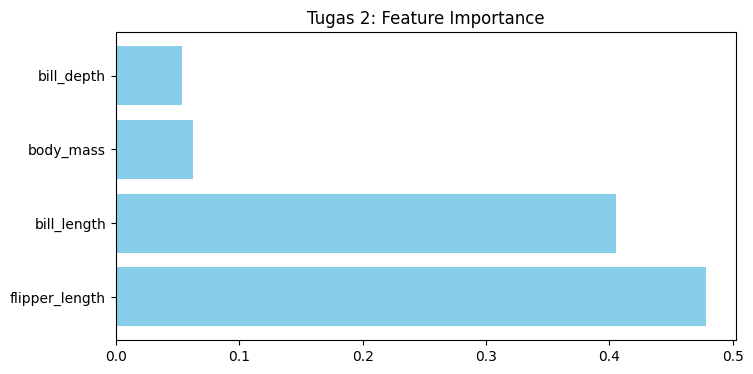

In [5]:
# ============================================================
# Tugas 2: Top 10 Feature Importance dari Random Forest
# ============================================================
print("\n" + "=" * 55)
print("Tugas 2: Top 10 Feature Importance (Random Forest)")
print("=" * 55)

rf = models["RandomForest"]
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for rank, idx in enumerate(indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]:30s} importance: {importances[idx]:.4f}")

# Visualisasi Fitur (Opsional agar grafik muncul)

plt.figure(figsize=(8, 4))
plt.barh([feature_names[i] for i in indices], importances[indices], color='skyblue')
plt.title("Tugas 2: Feature Importance")
plt.show()



Tugas 2 : Tampilkan 10 fitur terpenting dari Random Forest.

Tujuan dari tugas ini untuk melihat isi kepala dari model random forest saya. saya ingin tahu fitur mana saja dari fisik penguin (seperti panjang sirip atau berat badan) yang paling dianggap penting oleh model dalam menentukan spesiesnya. dengan begini dapat diketahui var apa yang paling berpengaruh dalam proses pengambilan keputusan AI.

Langkah kerja :
1. mengambil model random forest yang sudah dilatih pada tugas 1 untuk dianalisis lebih lanjut.
2. menggunakan atribut feature_importances_ untuk melihat nilai kontribusi dari masing-masing fitur.
3. mengurutkan fitur dari yang paling berpengaruh sampai yang kurang penting menggunakan fungsi argsort.
4. menampilkan daftar peringkat fitur dalam bentuk teks agar mudah dibawa.
5. menggambar grafik batas horizontal menggunakan matplotlib agar perbandingan tingkat kepentingan fiturnya terlihat jelas.

Penjelasan kode, saya menggunakan beberapa fungsi untuk melakukan audit fitur :
1. rf.feature_importances_ : ini adalah fitur bawaan random forest yang secara otomatis menghitung seberapa besar pengaruh setiap kolom terhadap hasil prediksi.
2. np.argsort(importances)[::-1] : karena urutan aslinya berantakan, saya pakai fungsi ini untuk mengurutkan dari yang nilai paling besar ke kecil.
3. plt.barh() : saya pakai grafik batang menyamping biar label nama fiturnya lebih enak dibaca dan tidak tumpang tindih
4. enumerate(indices, 1) : digunakan untuk membuat penomoran otomatis saat saya mencetak daftar fitur terbaik dilayar.

Kesimpulan singkat : Saya sadar kalau tidak semua data itu punya pengaruh yang sama. Ada fitur yang jadi "kunci utama" (seperti panjang sirip), dan ada juga yang cuma jadi pelengkap. Mengetahui Feature Importance ini sangat berguna bagi saya untuk menyederhanakan model.


=== Output 3: Eksperimen n_estimators ===
n_estimators: 1 | Accuracy: 0.95
n_estimators: 10 | Accuracy: 0.9
n_estimators: 50 | Accuracy: 0.9
n_estimators: 100 | Accuracy: 0.9
n_estimators: 200 | Accuracy: 0.9


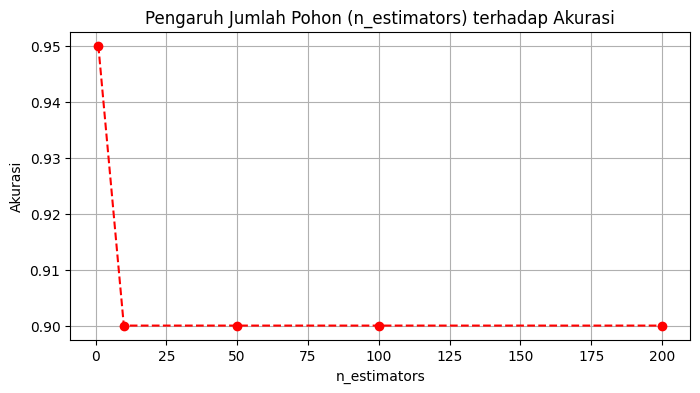

In [6]:
# ============================================================
# 3. PENGARUH N_ESTIMATORS PADA AKURASI
# ============================================================
print("\n=== Output 3: Eksperimen n_estimators ===")
n_list = [1, 10, 50, 100, 200]
est_results = []

for n in n_list:
    temp_model = RandomForestClassifier(n_estimators=n, random_state=42)
    temp_model.fit(X_train, y_train)
    acc = accuracy_score(y_test, temp_model.predict(X_test))
    est_results.append(acc)
    print(f"n_estimators: {n} | Accuracy: {round(acc, 3)}")

# Visualisasi Pengaruh n_estimators

plt.figure(figsize=(8, 4))
plt.plot(n_list, est_results, marker='o', color='red', linestyle='--')
plt.title("Pengaruh Jumlah Pohon (n_estimators) terhadap Akurasi")
plt.xlabel("n_estimators")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()


Tugas 3 : Coba ubah n_estimatorsdan lihat pengaruhnya.

Tujuan dari tugas ini untuk menguji jumlah pohon (n_estimators) dalam model random forest terhadap akurasi prediksi. saya ingin melihat apakah menambah jumlah pohon akan bikin model saya makin pintar atau malah bikin berat proses tanpa peningkatan akurasi.

Langkah kerja :
1. membuat daftar jumlah pohon yang mau dites, mulai dari yang paling sedikit (1 pohon) sampai yang lumayan banyak (200 pohon)
2. menjalankan perulangan untuk melatih model random forest berulang kali menggunakan jumlah pohin yang berbeda-beda.
3. menyimpan hasil skor akurasi dari setiap jumlah pohon kedalam sebuah list agar bisa dibandingkan
4. menggambar grafik garis untuk melihat nai-turunnya akurasi seiring bertambahnya jumlah pohon.
5. melihat titik dimana akurasi mulai stabil untuk menentukan jumlah pohon yang paling efisien.

Penjelasan kode :
1. n_list = [1, 10, 50, 100, 200] : ini adalah var soal kita. sayi ingin tahu bedanya kalau cuma pakai 1 pohon dibandingkan dengan 200 pohon.
2. RandomForestClassifier(n_estimators=n) : didalam loop, nilai n akan berubah sesuai n_list. fungsi ini akan membentuk hutan dengan jumlah pohon sebanyak n tersebut.
3. plt.plot(.., marker='o', linestyle='--') : saya pakai grafik garis dengan penanda titik (marker = 'o') dan garis putus biar kelihatan jelas diangka berapa akurasinya melonjak.
4. plt.grid(True) : saya aktifkan kotak dilatar belakang grafik biar lebih gampang baca nilai akurasinya di sumbu Y

Kesimpulan singkat : Dari grafik yang dihasilkan, saya bisa menyimpulkan bahwa menambah jumlah pohon biasanya bakal meningkatkan akurasi secara signifikan di awal, tapi lama-lama bakal mencapai titik jenuh di mana akurasinya stabil. Pelajaran buat saya adalah: nggak perlu pakai pohon ribuan kalau pakai 100 pohon saja akurasinya sudah mentok, karena itu cuma bakal buang-buang waktu loading kodingan saya saja.